In [1]:
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_RNA.h5ad
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_protein.h5ad
!pip install pyro-ppl graphviz seaborn anndata

File ‘PapalexiSatija2021_eccite_RNA.h5ad’ already there; not retrieving.

File ‘PapalexiSatija2021_eccite_protein.h5ad’ already there; not retrieving.


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import multiprocessing

multiprocessing.cpu_count()

10

In [3]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import pyro.distributions as dist
from pyro.infer import (
    SVI,
    TraceEnum_ELBO,
    Trace_ELBO,
    TraceMeanField_ELBO,
    JitTraceEnum_ELBO,
    config_enumerate,
    infer_discrete,
)

from torch.utils.data import (
    Dataset,
    Sampler,
    DataLoader,
    WeightedRandomSampler,
    SubsetRandomSampler,
    BatchSampler,
)

from pyro.optim import Adam, ClippedAdam
from pyro.ops.indexing import Vindex

from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, AutoDelta, init_to_median, init_to_value
import sys
from tqdm import tqdm

if torch.cuda.is_available():
    print("Let's ride")
    device = "cuda"
    torch.set_float32_matmul_precision("high")
    # torch.set_default_device("cuda")
    smoke_test = False
else:
    device = "cpu"
    smoke_test = True
smoke_test = True


In [4]:
adata = ad.read("PapalexiSatija2021_eccite_RNA.h5ad")
adata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [5]:
prot_adata = ad.read("PapalexiSatija2021_eccite_protein.h5ad")
prot_adata.var_names = prot_adata.var_names + "_protein"

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [6]:
prot_df = prot_adata.to_df().join(prot_adata.obs)
prot_df


,CD86_protein,PDL1_protein,PDL2_protein,CD366_protein,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,...,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,118.0,522.0,94.0,67.0,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,801.0,0.0,0.0
AAACCTGAGTGGACGT,243.0,139.0,104.0,59.0,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,545.0,0.0,0.0
AAACCTGCATGAGCGA,99.0,109.0,56.0,80.0,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,344.0,0.0,0.0
AAACCTGTCTTGTCAT,110.0,334.0,48.0,47.0,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,539.0,0.0,0.0
AAACGGGAGAACAACT,303.0,593.0,77.0,80.0,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,1053.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,98.0,151.0,135.0,14.0,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,398.0,0.0,0.0
TTTGTCAGTGACGGTA,1781.0,1117.0,89.0,55.0,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,0,4,3042.0,0.0,0.0
TTTGTCAGTTCCACAA,84.0,73.0,38.0,17.0,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,212.0,0.0,0.0
TTTGTCATCACGCATA,18.0,135.0,37.0,68.0,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,258.0,0.0,0.0


In [7]:
# adata = ad.concat((prot_adata, adata), axis=1, merge="first")
# adata

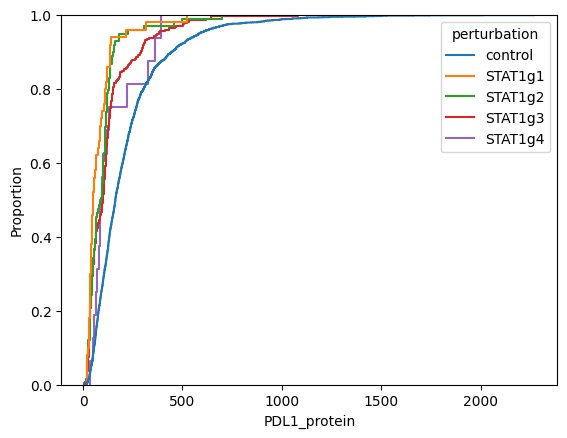

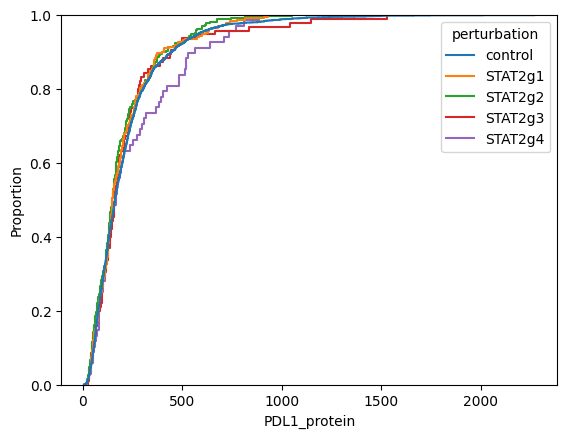

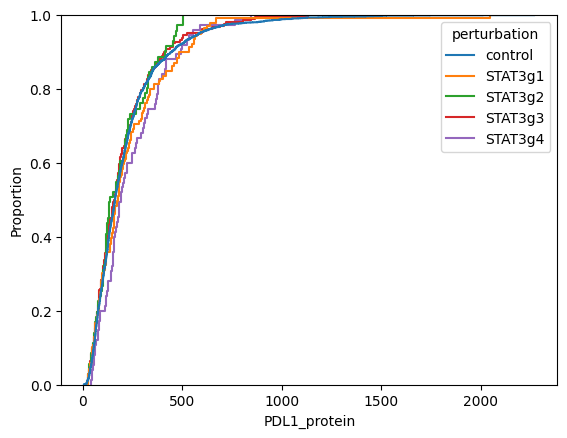

In [8]:
plot_gene = "STAT1"
for plot_gene in ["STAT1", "STAT2", "STAT3"]:
    sns.ecdfplot(prot_df, hue="perturbation", x="PDL1_protein", hue_order=["control"]+[f"{plot_gene}g{i}" for i in range(1,5)])
    plt.show()

In [9]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578


In [10]:
n_mito = adata[:, adata.var_names.str.startswith("MT-")].X.sum(axis=1).A1
n_rps = adata[:, adata.var_names.str.match("RPS[0-9]+")].X.sum(axis=1).A1
n_rpl = adata[:, adata.var_names.str.match("RPL[0-9]+")].X.sum(axis=1).A1
n_ribo = n_rps + n_rpl
n_total = adata.X.sum(axis=1).A1
# adata.obs
# plt.scatter(n_total, n_ribo, alpha=0.1)
# plt.scatter(n_total, n_mito, alpha=0.1)
# plt.scatter(n_ribo, n_mito, alpha=0.1)

In [11]:
adata.obs = adata.obs.assign(
    element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True)
)
adata.obs["element"]

AAACCTGAGCCAGAAC      STAT2
AAACCTGAGTGGACGT       CAV1
AAACCTGCATGAGCGA      STAT1
AAACCTGTCTTGTCAT       CD86
AAACGGGAGAACAACT       IRF7
                     ...   
TTTGTCAGTCACTTCC      CMTM6
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA       ATF2
TTTGTCATCACGCATA       CAV1
TTTGTCATCTGTACGA      STAT3
Name: element, Length: 20729, dtype: object

In [12]:
# pick a subset of random genes including 3 known ones
# stat_target_genes = ["STAT1", "STAT2", "IRF1"]

# pick a subset of 50 genes including all perturbed ones

if smoke_test:
    n_genes_subset = 50
    target_genes = [e for e in adata.obs["element"].unique() if e != "control"]
    # target_genes += prot_adata.var_names.tolist()
    other_genes = [gene for gene in adata.var_names if gene not in target_genes]
    selected_genes = target_genes + other_genes[: n_genes_subset - len(target_genes)]
    # selected_genes = stat_target_genes + list(
    #     np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
    # )

    # selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
    # guide_filter = adata.obs["perturbation"].isin(selected_guides)
    # adata_subset = adata[guide_filter, :][:, selected_genes]
    adata_subset = adata[:, selected_genes]

else:
    min_counts = 100 # min no. of cells with at least 1 count
    selected_genes = ((adata.X>0).sum(axis=0)) > min_counts
    adata_subset = adata[:, selected_genes]
adata_subset

View of AnnData object with n_obs × n_vars = 20729 × 50
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [13]:
adata_subset.var_names

Index(['STAT2', 'CAV1', 'STAT1', 'CD86', 'IRF7', 'ATF2', 'STAT3', 'JAK2',
       'NFKBIA', 'SMAD4', 'STAT5A', 'CMTM6', 'IFNGR1', 'UBE2L6', 'PDCD1LG2',
       'CUL3', 'BRD4', 'MARCH8', 'IRF1', 'POU2F2', 'ETV7', 'IFNGR2',
       'TNFRSF14', 'SPI1', 'MYC', 'AL627309.1', 'AP006222.2', 'RP4-669L17.10',
       'RP11-206L10.3', 'RP11-206L10.2', 'RP11-206L10.9', 'LINC00115',
       'FAM41C', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4', 'ISG15',
       'AGRN', 'RP11-54O7.18', 'C1orf159', 'TNFRSF18', 'TNFRSF4', 'SDF4',
       'B3GALT6', 'FAM132A', 'RP5-902P8.12', 'UBE2J2', 'SCNN1D'],
      dtype='object', name='gene_symbol')

In [14]:
# from siphon.module import train
import mudata as md
grna_observed = pd.get_dummies(adata_subset.obs["guide_id"]).astype(int)

In [15]:
guide_by_element = (
    pd.crosstab(adata_subset.obs["guide_id"], adata_subset.obs["element"])
    .reindex(index=grna_observed.columns)
    > 0
).astype(int)
guide_by_element

element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6,control
ATF2g1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRD4g1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFRSF14g4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
UBE2L6g1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [16]:

gdata = ad.AnnData(grna_observed, varm={"guide_targets": guide_by_element})
mdata = md.MuData({"rna":adata_subset, "grna":gdata})
mdata

MuData object with n_obs × n_vars = 20729 × 157
  2 modalities
    rna:	20729 x 50
      obs:	'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
      var:	'ensembl_id', 'ncounts', 'ncells'
    grna:	20729 x 107
      varm:	'guide_targets'

In [17]:
mdata["rna"].obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [18]:
import perturbo
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="hto",
    library_size_key="ncounts",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    guide_by_element_key="guide_targets",
    # gene_by_element_key="element_tested",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood="nb", low_moi=True, n_factors=5)
model.view_anndata_setup()


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


INFO     Using column names from columns of adata.varm['guide_targets']                                            


/Users/ljb80/Projects/perturbo/src/perturbo/models/_model.py:231: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mdata[modalities.rna_layer].obs[size_factor_key] = log_cpm - log_cpm.mean()
<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

/Users/ljb80/.virtualenvs/perturbo-dev/lib/pyth

Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

...

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   5   │
│         n_cells         │ 20729 │
│ n_extra_continuous_covs │   2   │
│  n_gene_summary_stats   │   1   │
│     n_perturbations     │  107  │
│   n_targeted_elements   │  26   │
│         n_vars          │  50   │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│  gene_summary_stats   │  adata.mod['rna'].varm['_scvi_gene_summary_stats']   │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │       adata.mod['grna'].varm['guide_targets']        │
└───────────────────────┴──────────────────────────────────────────────────────┘

                 batch State Registry                  
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['hto'] │  rep1-tx   │          0          │
│                  │ rep2-ctrl  │          1          │
│                  │  rep2-tx   │          2          │
│                  │  rep3-tx   │          3          │
│                  │  rep4-tx   │          4          │
└──────────────────┴────────────┴─────────────────────┘

 gene_summary_stats State  
         Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.var['_gene_mean'] │
└─────────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
│ adata.obs['percent_ribo'] │
└───────────────────────────┘

In [19]:
model.train(
    100,
    lr=0.01,
    batch_size=512,
    # callbacks=[checkpoint_callback],
    # enable_checkpointing=True,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_min_delta=1e-3,
    early_stopping_monitor="elbo_train",
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 96/100:  96%|█████████▌| 96/100 [01:30<00:03,  1.06it/s, v_num=1, elbo_train=1.02e+6]
Monitored metric elbo_train did not improve in the last 5 records. Best score: 1015891.688. Signaling Trainer to stop.


In [20]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)


AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.scales.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([3, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([3, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([3, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([3, 1, 50])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuide

In [21]:
# plt.scatter(siphon_model.dataset.size_factor, siphon_model.guide.median()["size_factor_fit"], alpha=0.01)

In [22]:
# plt.plot(losses)

In [23]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)

AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.scales.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([3, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([3, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([3, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([3, 1, 50])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuide

In [29]:
guide=model.module.guide
guides = mdata["grna"].var_names
elements = guide_by_element.index
guide.median().keys()

dict_keys(['guide_efficacy', 'pert_factors', 'pert_loadings', 'cell_factors', 'cell_loadings', 'log_gene_mean', 'log_gene_dispersion', 'batch_effect', 'cont_covariate_effect', 'element_effects'])

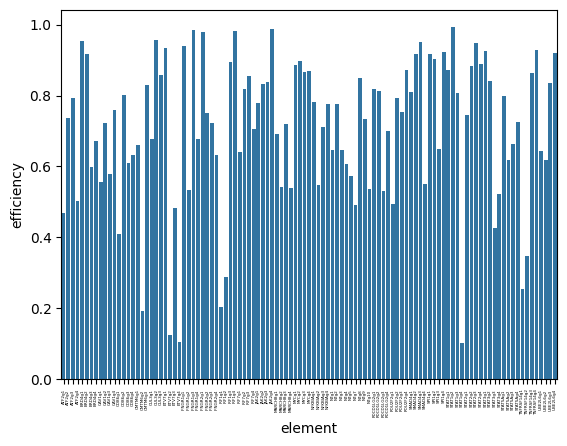

In [89]:
elements = guide_by_element.index
if "guide_efficacy" in guide.median():
    element_efficiency = pd.DataFrame(
        guide.median()["guide_efficacy"].detach().cpu(),
        index=elements,
        columns=["efficiency"],
    ).reset_index(names="element")
    element_efficiency
    sns.barplot(element_efficiency, x="element", y="efficiency")
    plt.xticks(rotation=90, size=3)

array([[<Axes: title={'center': 'efficiency'}>]], dtype=object)

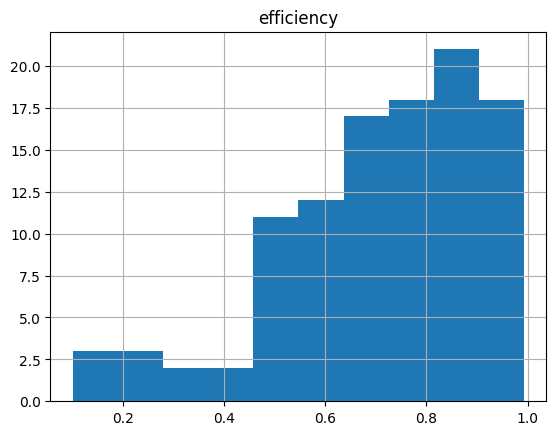

In [30]:
median_efficiency = pd.DataFrame(
    guide.median()["guide_efficacy"].detach().cpu(),
    index=guides,
    columns=["efficiency"],
).assign(
    guide=lambda x: x.index,
    element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
)
median_efficiency.hist("efficiency")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, 'ATF2'),
  Text(1, 0, 'BRD4'),
  Text(2, 0, 'CAV1'),
  Text(3, 0, 'CD86'),
  Text(4, 0, 'CMTM6'),
  Text(5, 0, 'CUL3'),
  Text(6, 0, 'ETV7'),
  Text(7, 0, 'IFNGR1'),
  Text(8, 0, 'IFNGR2'),
  Text(9, 0, 'IRF1'),
  Text(10, 0, 'IRF7'),
  Text(11, 0, 'JAK2'),
  Text(12, 0, 'MARCH8'),
  Text(13, 0, 'MYC'),
  Text(14, 0, 'NFKBIA'),
  Text(15, 0, 'NT'),
  Text(16, 0, 'PDCD1LG2'),
  Text(17, 0, 'POU2F2'),
  Text(18, 0, 'SMAD4'),
  Text(19, 0, 'SPI1'),
  Text(20, 0, 'STAT1'),
  Text(21, 0, 'STAT2'),
  Text(22, 0, 'STAT3'),
  Text(23, 0, 'STAT5A'),
  Text(24, 0, 'TNFRSF14'),
  Text(25, 0, 'UBE2L6')])

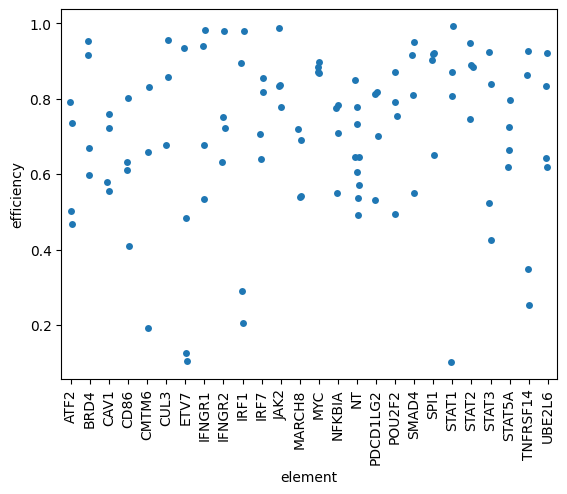

In [31]:
sns.stripplot(median_efficiency, x="element", y="efficiency")
plt.xticks(rotation=90)

In [61]:
effects_df_long = model.get_element_effects()
effects_df_long

,element,gene,loc,scale,z_value,q_value
479,JAK2,IRF1,-1.729107,0.039877,-43.361549,0.000000e+00
476,IFNGR2,IRF1,-1.585368,0.045334,-34.970680,6.280467e-268
1008,STAT2,ISG15,-1.909943,0.066333,-28.793062,2.619952e-182
487,STAT1,IRF1,-2.072922,0.075488,-27.460138,5.257601e-166
475,IFNGR1,IRF1,-1.459153,0.054324,-26.860361,6.383417e-159
...,...,...,...,...,...,...
31,CUL3,CAV1,2.936810,0.296970,9.889236,4.635500e-23
996,IFNGR2,ISG15,0.451872,0.033436,13.514719,1.280437e-41
511,SMAD4,POU2F2,1.135283,0.080336,14.131650,2.423969e-45
999,JAK2,ISG15,0.605771,0.036662,16.522938,2.508742e-61


In [62]:
effects_df = effects_df_long.pivot_table(values="loc", index="element", columns="gene")
effects_df

gene,AGRN,AL627309.1,AP006222.2,ATF2,B3GALT6,BRD4,C1orf159,CAV1,CD86,CMTM6,...,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,TNFRSF18,TNFRSF4,UBE2J2,UBE2L6
element,,,,,,,,,,,,,,,,,,,,,
ATF2,-0.010524,0.001695,0.003200,-0.058941,-0.005607,-0.014973,-0.006919,-0.011489,0.033829,0.038507,...,-0.003496,0.000564,0.003176,-0.013022,-0.007939,-0.015810,-0.004858,0.013126,-0.037132,-0.005490
BRD4,0.020603,0.010160,-0.013427,-0.002595,-0.011934,-0.757773,-0.003619,0.006417,-0.616387,-0.008694,...,-0.104874,0.038928,-0.016237,0.007892,-0.007657,0.019100,0.002653,-0.017584,-0.041741,0.011725
CAV1,0.002593,-0.005978,0.021765,0.009439,-0.012622,-0.012039,0.007936,-0.000272,0.019924,0.031833,...,-0.005731,0.008656,0.017809,-0.004402,-0.012232,0.005259,0.017919,0.008478,-0.018254,-0.023323
CD86,-0.019676,-0.010761,-0.002287,0.017175,-0.012075,-0.003896,0.010569,0.005321,-0.031829,0.017357,...,0.015018,-0.009448,-0.024659,-0.018169,0.025710,0.010850,0.003531,-0.009339,0.011469,0.012700
CMTM6,-0.007480,0.003517,-0.001298,-0.008154,-0.015265,-0.003315,0.001735,0.022081,0.006050,-0.846905,...,0.029018,-0.048443,-0.004476,-0.007990,-0.017379,0.024127,-0.010745,0.027617,-0.021386,-0.008663
CUL3,-0.000528,-0.002819,0.008522,-0.000450,0.020005,-0.005011,0.025380,2.936810,0.012568,-0.018561,...,0.006994,-0.005537,-0.032877,-0.003244,0.006557,-0.007798,-0.007223,0.015920,-0.021375,-0.018881
ETV7,-0.022728,-0.004276,-0.007721,0.005961,0.010341,-0.021377,-0.001344,-0.014872,-0.004185,-0.002224,...,-0.004925,0.009765,0.012149,0.021282,-0.009373,0.011500,0.007372,-0.006853,0.017509,-0.004789
IFNGR1,0.022594,0.010748,0.017217,-0.004494,0.029368,-0.012965,-0.005644,0.003623,-0.011840,-0.002098,...,-0.001277,-0.494372,-0.009326,-0.044520,0.006085,-0.004488,-0.028026,0.009689,0.004909,-0.355651
IFNGR2,0.003858,0.003036,-0.023336,-0.015204,-0.012947,0.008757,-0.010581,0.025835,0.003383,-0.010352,...,-0.001703,-0.553604,-0.025660,0.015567,0.021976,0.024400,-0.024807,0.015678,0.000411,-0.405629


In [63]:
cis_effects = effects_df_long.query("element==gene")
cis_effects

,element,gene,loc,scale,z_value,q_value
554,IFNGR2,IFNGR2,-0.870980,0.037427,-23.271631,8.592784e-120
71,STAT1,STAT1,-2.502593,0.109535,-22.847359,1.552501e-115
290,CMTM6,CMTM6,-0.846905,0.052830,-16.030651,7.806032e-58
193,JAK2,JAK2,-1.217921,0.081085,-15.020354,5.401835e-51
222,NFKBIA,NFKBIA,-0.893957,0.080870,-11.054205,2.091817e-28
595,TNFRSF14,TNFRSF14,-0.827741,0.076195,-10.863501,1.720255e-27
526,ETV7,ETV7,-0.752277,0.072906,-10.318510,5.811803e-25
362,UBE2L6,UBE2L6,-0.497531,0.048702,-10.215814,1.684600e-24
20,STAT2,STAT2,-0.825702,0.081079,-10.183871,2.340602e-24
417,BRD4,BRD4,-0.757773,0.081316,-9.318868,1.175886e-20


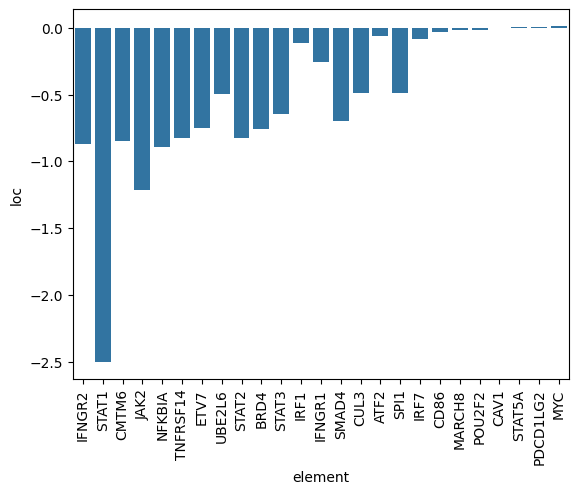

In [64]:
# median_cis_effect = guide.median()["cis_effect"].detach().cpu()
# low_cis_effect, high_cis_effect = (
    # guide.quantiles([0.159, 0.841])["cis_effect"].detach().cpu()
# )
# sigma_cis_effect = high_cis_effect - median_cis_effect
# z_score_cis_effect = median_cis_effect / sigma_cis_effect

sns.barplot(cis_effects, x="element", y="loc")
plt.xticks(rotation=90)
plt.show()

# sns.barplot(x=elements, y=z_score_cis_effect.squeeze())

# plt.xticks(rotation=90)
# plt.show()

In [65]:
# effects_df = effects
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

# median_effect = guide.median()["trans_effect"].detach().cpu()
# low_effect, high_effect = guide.quantiles([0.159, 0.841])["trans_effect"].detach().cpu()
# sigma_effect = high_effect - low_effect
# z_score_effect = median_effect / sigma_effect

# effects_df = pd.DataFrame(
#     effects,
#     # z_score_effect,
#     columns=adata_subset.var_names,
#     index=elements,
# )
# effects_df

# effects_df = pd.DataFrame(
#     median_effect,
#     columns=adata_subset.var_names,
#     index=list(element_mapping.keys())[:n_elements],
# )
# effects_df

In [66]:

plot_genes = [g for g in list(cis_effects["element"]) if g != "control"]
plot_genes

['IFNGR2',
 'STAT1',
 'CMTM6',
 'JAK2',
 'NFKBIA',
 'TNFRSF14',
 'ETV7',
 'UBE2L6',
 'STAT2',
 'BRD4',
 'STAT3',
 'IRF1',
 'IFNGR1',
 'SMAD4',
 'CUL3',
 'ATF2',
 'SPI1',
 'IRF7',
 'CD86',
 'MARCH8',
 'POU2F2',
 'CAV1',
 'STAT5A',
 'PDCD1LG2',
 'MYC']

In [69]:
# effect_variance = effects_df.var(axis=0)
effect_variance = effects_df_long.groupby("gene")["loc"].var()
# effect_variance = (effects_df.abs() > 5).sum(axis=0)
# effect_variance = (effects_df.loc[["STAT3", "STAT5A", "CAV1", "CD86"]].abs()).sum(
#     axis=0
# )
hvgs = effect_variance.nlargest(50).index.tolist()
hvgs
# effects_df[effects_df["gene"].isin(hvgs)]


['ETV7',
 'ISG15',
 'IRF1',
 'CAV1',
 'STAT1',
 'JAK2',
 'UBE2L6',
 'IRF7',
 'TNFRSF4',
 'TNFRSF14',
 'STAT2',
 'POU2F2',
 'NFKBIA',
 'HES4',
 'IFNGR2',
 'AGRN',
 'CD86',
 'CMTM6',
 'BRD4',
 'SMAD4',
 'STAT3',
 'PDCD1LG2',
 'MYC',
 'CUL3',
 'SPI1',
 'IFNGR1',
 'SDF4',
 'STAT5A',
 'ATF2',
 'UBE2J2',
 'NOC2L',
 'RP5-902P8.12',
 'AP006222.2',
 'SAMD11',
 'RP11-54O7.18',
 'RP4-669L17.10',
 'RP11-206L10.2',
 'TNFRSF18',
 'KLHL17',
 'B3GALT6',
 'C1orf159',
 'FAM41C',
 'LINC00115',
 'PLEKHN1',
 'FAM132A',
 'AL627309.1',
 'SCNN1D',
 'RP11-206L10.9',
 'RP11-206L10.3',
 'MARCH8']

In [70]:
# plt.scatter(guide.median()["gene_mean"].cpu().log(), guide.median()["dispersion"].cpu().log(), alpha=0.1)

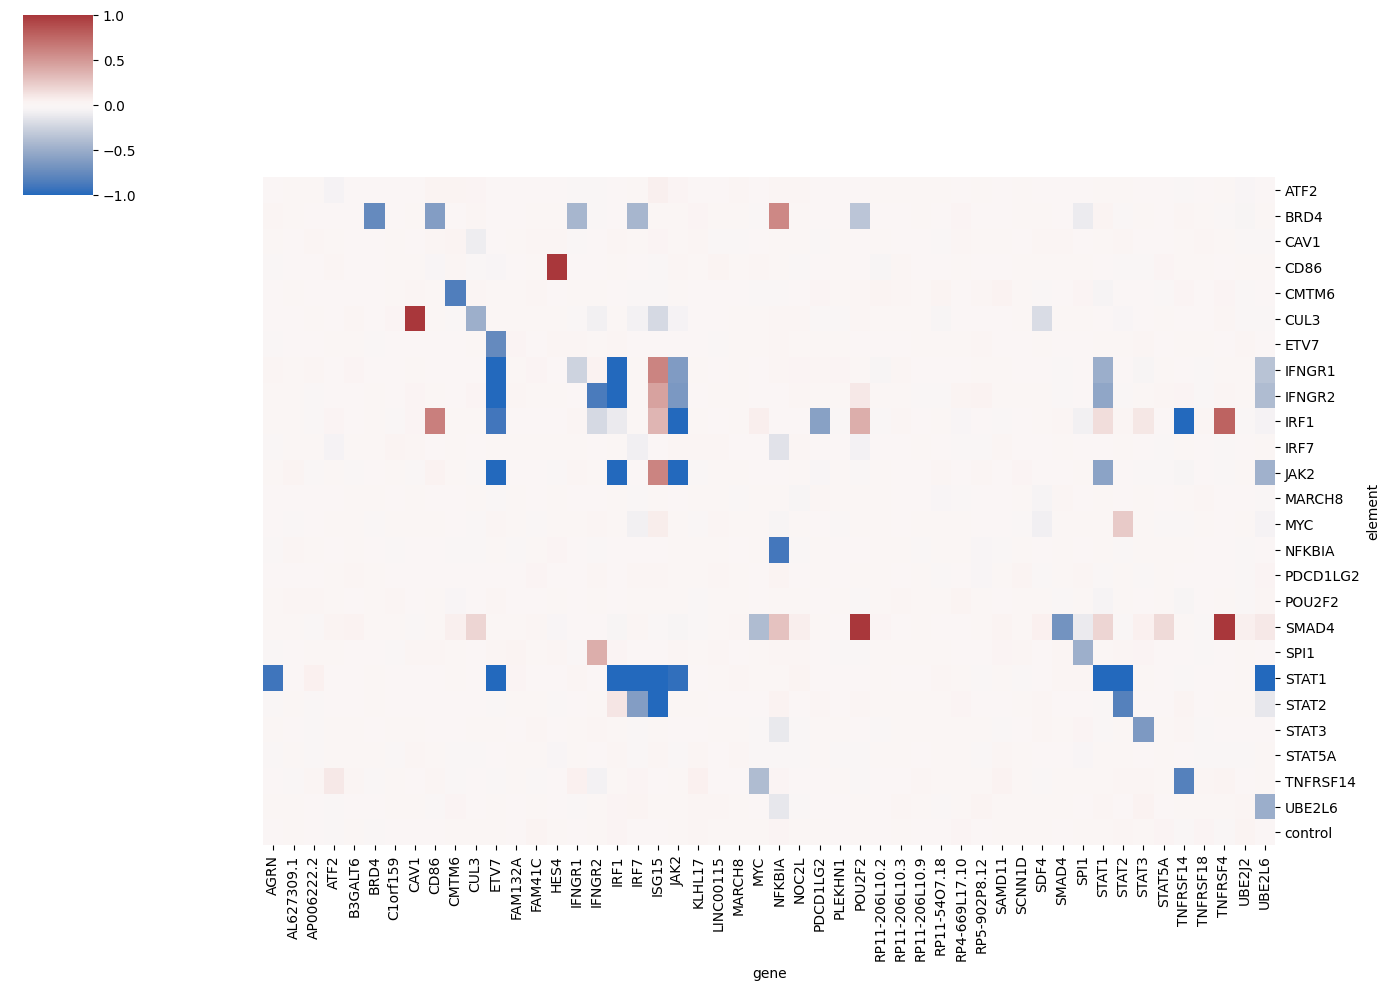

In [74]:
sns.clustermap(
    effects_df,
    vmax=1,
    vmin=-1,
    cmap="vlag",
    metric="cosine",
    figsize=(14, 10),
    col_cluster=False,
    row_cluster=False
)

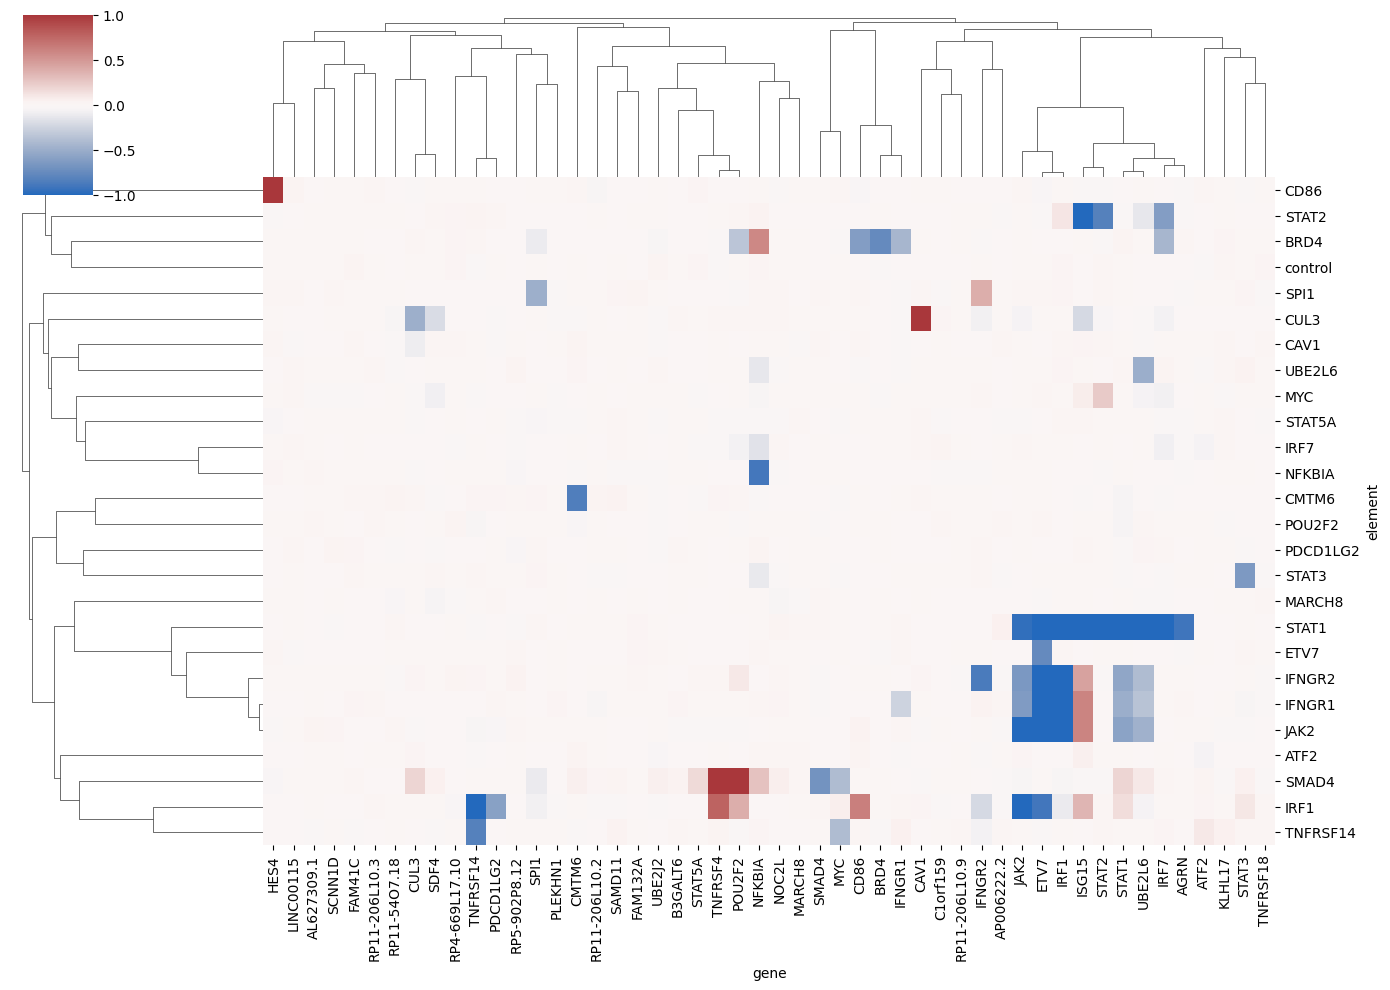

In [75]:
sns.clustermap(
    effects_df[hvgs], vmax=1, vmin=-1, cmap="vlag", metric="cosine", figsize=(14, 10)
)

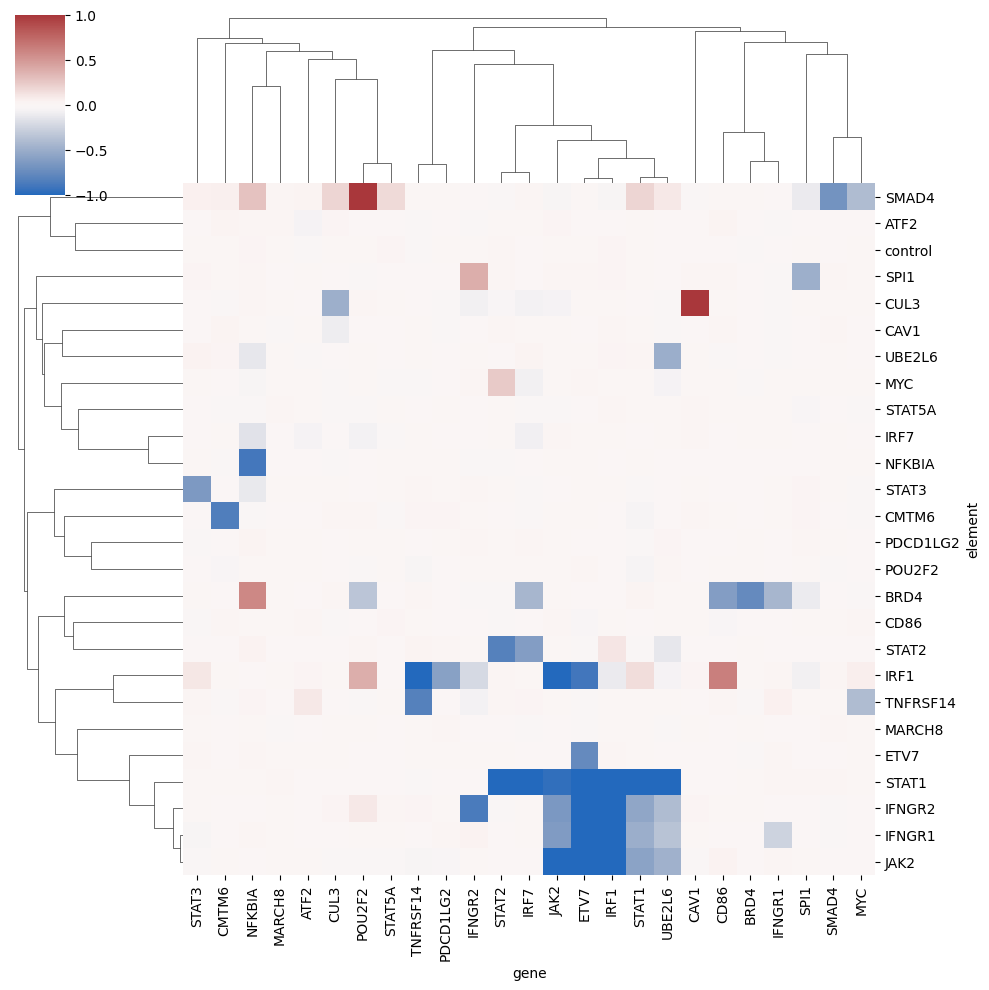

In [77]:
sns.clustermap(
    effects_df[[g for g in plot_genes if g in effects_df.columns]], vmax=1, vmin=-1, cmap="vlag", metric="cosine", figsize=(10, 10)
)

In [78]:
if not smoke_test:
    pyro.get_param_store().save("params.save")

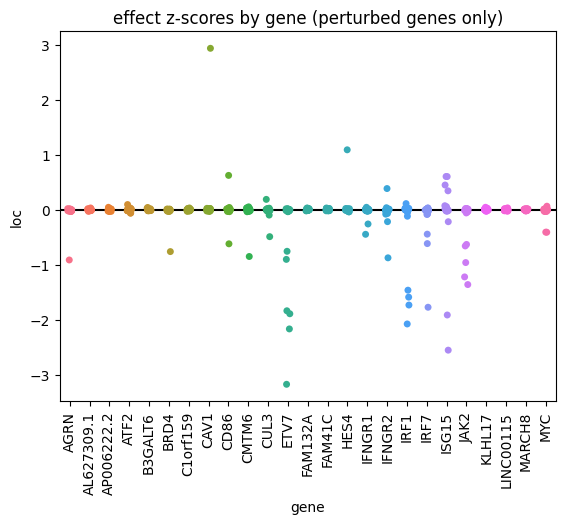

In [81]:
n_plot_genes = 25
sns.stripplot(effects_df.iloc[:, :n_plot_genes])
# sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
#
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.ylabel("loc")
plt.title("effect z-scores by gene (perturbed genes only)")
plt.show()

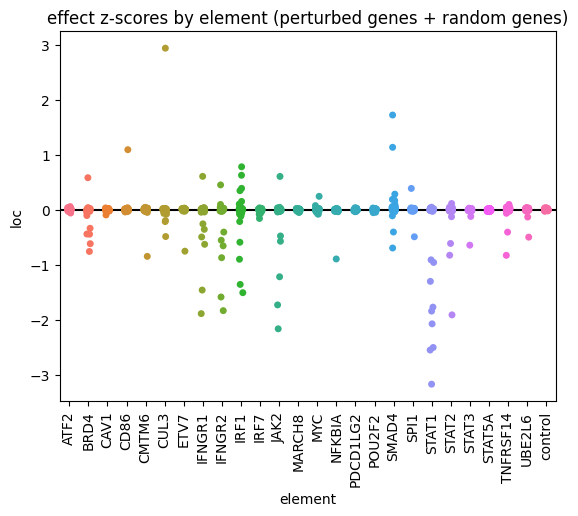

In [82]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.ylabel("loc")
plt.xlabel("element")
plt.title("effect z-scores by element (perturbed genes + random genes)")
plt.show()

In [83]:
effects_df.T["CMTM6"].sort_values()

gene
CMTM6           -0.846905
STAT1           -0.048443
SDF4            -0.030038
NFKBIA          -0.028756
MYC             -0.026267
UBE2J2          -0.021386
IRF7            -0.019288
STAT5A          -0.017379
ISG15           -0.015997
B3GALT6         -0.015265
HES4            -0.013894
NOC2L           -0.012999
RP4-669L17.10   -0.011340
TNFRSF18        -0.010745
LINC00115       -0.009496
UBE2L6          -0.008663
ATF2            -0.008154
STAT3           -0.007990
MARCH8          -0.007813
AGRN            -0.007480
KLHL17          -0.006144
STAT2           -0.004476
IRF1            -0.004423
BRD4            -0.003315
AP006222.2      -0.001298
SMAD4           -0.001020
PLEKHN1          0.001521
C1orf159         0.001735
SCNN1D           0.002105
IFNGR1           0.002596
AL627309.1       0.003517
ETV7             0.003773
CD86             0.006050
FAM132A          0.007237
JAK2             0.008810
IFNGR2           0.011206
RP11-206L10.9    0.014533
CUL3             0.016273
RP5-902